In [1]:
import pandas as pd
import numpy as np
import random as rd
import matplotlib.pyplot as plt

In [2]:

import warnings
warnings.filterwarnings('ignore')

In [3]:
clustering_data = pd.read_csv('clustering.csv')
clustering_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


In [4]:
clustering_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    str    
 1   Gender             376 non-null    str    
 2   Married            381 non-null    str    
 3   Dependents         373 non-null    str    
 4   Education          381 non-null    str    
 5   Self_Employed      360 non-null    str    
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   370 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Property_Area      381 non-null    str    
 12  Loan_Status        381 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 51.9 KB


In [5]:
clustering_data.isna().sum()

Loan_ID               0
Gender                5
Married               0
Dependents            8
Education             0
Self_Employed        21
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     11
Credit_History       30
Property_Area         0
Loan_Status           0
dtype: int64

In [6]:
clustering_data.dropna(inplace=True)    

In [7]:
clustering_data.shape

(308, 13)

Text(0, 0.5, 'Loan Amount (In Thousands)')

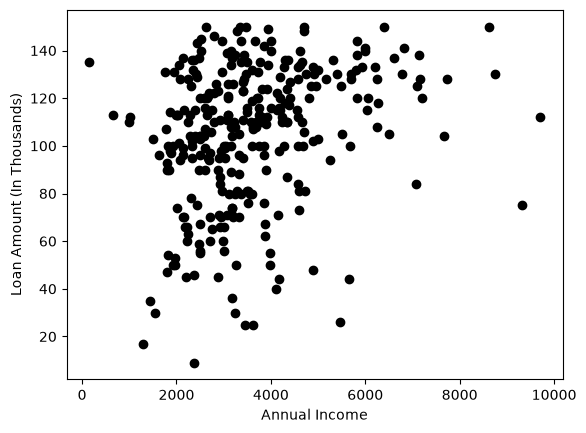

In [8]:
X = clustering_data[['LoanAmount','ApplicantIncome']]
plt.scatter(X['ApplicantIncome'], X['LoanAmount'], c='black')
plt.xlabel('Annual Income')
plt.ylabel('Loan Amount (In Thousands)')


In [9]:
from sklearn.cluster import KMeans

In [10]:
data = clustering_data.drop('Loan_ID',axis=1)
data.shape

(308, 12)

In [11]:
data.Gender.value_counts()

Gender
Male      245
Female     63
Name: count, dtype: int64

In [12]:
data.Married.value_counts()

Married
Yes    185
No     123
Name: count, dtype: int64

In [13]:
data.Dependents.value_counts()

Dependents
0     194
2      47
1      43
3+     24
Name: count, dtype: int64

In [14]:
data.Dependents = data.Dependents.str.replace('+','')

In [15]:
data.info()

<class 'pandas.DataFrame'>
Index: 308 entries, 0 to 380
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             308 non-null    str    
 1   Married            308 non-null    str    
 2   Dependents         308 non-null    str    
 3   Education          308 non-null    str    
 4   Self_Employed      308 non-null    str    
 5   ApplicantIncome    308 non-null    int64  
 6   CoapplicantIncome  308 non-null    float64
 7   LoanAmount         308 non-null    float64
 8   Loan_Amount_Term   308 non-null    float64
 9   Credit_History     308 non-null    float64
 10  Property_Area      308 non-null    str    
 11  Loan_Status        308 non-null    str    
dtypes: float64(4), int64(1), str(7)
memory usage: 39.6 KB


In [16]:
data.Education.value_counts()

Education
Graduate        229
Not Graduate     79
Name: count, dtype: int64

In [17]:
data.Self_Employed.value_counts()

Self_Employed
No     280
Yes     28
Name: count, dtype: int64

In [18]:
data.Property_Area.value_counts()

Property_Area
Semiurban    123
Urban         99
Rural         86
Name: count, dtype: int64

In [19]:
data.Property_Area = data.Property_Area.apply(lambda x : 'Urban' if x=='Semiurban' else x)

In [20]:
data.Property_Area.value_counts()

Property_Area
Urban    222
Rural     86
Name: count, dtype: int64

In [21]:
data.Credit_History.value_counts()

Credit_History
1.0    263
0.0     45
Name: count, dtype: int64

In [22]:
data.Loan_Status.value_counts()

Loan_Status
Y    219
N     89
Name: count, dtype: int64

In [23]:
data.info()

<class 'pandas.DataFrame'>
Index: 308 entries, 0 to 380
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             308 non-null    str    
 1   Married            308 non-null    str    
 2   Dependents         308 non-null    str    
 3   Education          308 non-null    str    
 4   Self_Employed      308 non-null    str    
 5   ApplicantIncome    308 non-null    int64  
 6   CoapplicantIncome  308 non-null    float64
 7   LoanAmount         308 non-null    float64
 8   Loan_Amount_Term   308 non-null    float64
 9   Credit_History     308 non-null    float64
 10  Property_Area      308 non-null    str    
 11  Loan_Status        308 non-null    str    
dtypes: float64(4), int64(1), str(7)
memory usage: 39.1 KB


In [24]:
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


In [25]:
encoded = pd.get_dummies(data,dtype=int)
encoded.head(3)

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Female,Gender_Male,Married_No,Married_Yes,Dependents_0,...,Dependents_2,Dependents_3,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Urban,Loan_Status_N,Loan_Status_Y
0,4583,1508.0,128.0,360.0,1.0,0,1,0,1,0,...,0,0,1,0,1,0,1,0,1,0
1,3000,0.0,66.0,360.0,1.0,0,1,0,1,1,...,0,0,1,0,0,1,0,1,0,1
2,2583,2358.0,120.0,360.0,1.0,0,1,0,1,1,...,0,0,0,1,1,0,0,1,0,1


In [26]:
import warnings
warnings.filterwarnings('ignore')

In [27]:
kmeans = KMeans(n_clusters=2)


kmeans.fit(encoded)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](2, 21)"

In [28]:
kmeans.inertia_

1976439983.5737185

Text(0, 0.5, 'Inertia')

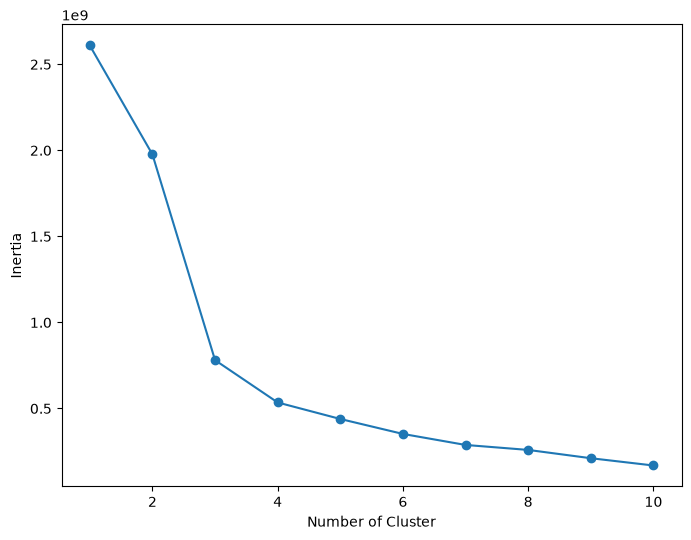

In [29]:
wcss = []
for cluster in range(1,11):
    kmeans = KMeans(n_clusters=cluster)
    kmeans.fit(encoded)
    wcss.append(kmeans.inertia_)

frame = pd.DataFrame({'Cluster':range(1,11),'wcss':wcss})
plt.figure(figsize=(8,6))
plt.plot(frame['Cluster'], frame['wcss'],marker='o')
plt.xlabel('Number of Cluster')
plt.ylabel('Inertia')

In [30]:
frame

,Cluster,wcss
0,1,2.609274e+09
1,2,1.976440e+09
2,3,7.809409e+08
3,4,5.349997e+08
4,5,4.390479e+08
5,6,3.521847e+08
6,7,2.881728e+08
7,8,2.592630e+08
8,9,2.111129e+08
9,10,1.687830e+08


In [31]:
kmeans = KMeans(n_clusters =3, init='k-means++')
kmeans.fit(encoded)
pred = kmeans.predict(encoded)

In [32]:
pred

array([0, 0, 2, 0, 2, 2, 2, 2, 0, 0, 0, 0, 2, 2, 0, 2, 0, 0, 2, 2, 2, 0,
       2, 2, 0, 0, 2, 2, 2, 0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 2, 0, 0, 2, 0,
       0, 2, 0, 0, 2, 2, 2, 2, 0, 0, 2, 2, 0, 2, 2, 2, 2, 0, 0, 2, 0, 2,
       0, 0, 0, 0, 2, 0, 2, 2, 2, 0, 0, 2, 0, 2, 2, 0, 0, 2, 2, 0, 0, 2,
       2, 0, 2, 0, 0, 2, 0, 0, 0, 2, 2, 0, 0, 0, 2, 2, 0, 2, 0, 2, 0, 2,
       2, 2, 2, 2, 0, 2, 2, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2, 2, 0, 2, 0, 0,
       2, 0, 0, 0, 2, 0, 2, 2, 0, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 0, 2, 0,
       2, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 0, 0, 2, 2, 2, 0, 0, 2, 0,
       2, 2, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 2, 2, 0, 2,
       2, 0, 2, 2, 2, 0, 0, 1, 2, 0, 2, 2, 0, 2, 0, 2, 2, 0, 2, 2, 0, 0,
       0, 0, 0, 0, 2, 0, 2, 0, 0, 2, 0, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0,
       2, 2, 2, 0, 0, 2, 2, 0, 2, 0, 2, 2, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2,
       0, 2, 2, 0, 0, 2, 0, 0, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 2, 0, 0, 0,
       0, 2, 2, 2, 0, 0, 2, 2, 1, 0, 2, 2, 2, 0, 2,

In [33]:
clustered = pd.DataFrame(encoded)
clustered['cluster'] = pred
clustered['cluster'].value_counts()

cluster
2    162
0    144
1      2
Name: count, dtype: int64

In [34]:
clustered

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Female,Gender_Male,Married_No,Married_Yes,Dependents_0,...,Dependents_3,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Urban,Loan_Status_N,Loan_Status_Y,cluster
0,4583,1508.0,128.0,360.0,1.0,0,1,0,1,0,...,0,1,0,1,0,1,0,1,0,0
1,3000,0.0,66.0,360.0,1.0,0,1,0,1,1,...,0,1,0,0,1,0,1,0,1,0
2,2583,2358.0,120.0,360.0,1.0,0,1,0,1,1,...,0,0,1,1,0,0,1,0,1,2
3,6000,0.0,141.0,360.0,1.0,0,1,1,0,1,...,0,1,0,1,0,0,1,0,1,0
4,2333,1516.0,95.0,360.0,1.0,0,1,0,1,1,...,0,0,1,1,0,0,1,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
376,5703,0.0,128.0,360.0,1.0,0,1,0,1,0,...,1,1,0,1,0,0,1,0,1,0
377,3232,1950.0,108.0,360.0,1.0,0,1,0,1,1,...,0,1,0,1,0,1,0,0,1,2
378,2900,0.0,71.0,360.0,1.0,1,0,1,0,1,...,0,1,0,1,0,1,0,0,1,0
379,4106,0.0,40.0,180.0,1.0,0,1,0,1,0,...,1,1,0,1,0,1,0,0,1,0


In [35]:
groups = clustered.groupby('cluster')

In [36]:
c0 = groups.get_group(0)
c1 = groups.get_group(1)
c2 = groups.get_group(2)

In [37]:
c2

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Female,Gender_Male,Married_No,Married_Yes,Dependents_0,...,Dependents_3,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Urban,Loan_Status_N,Loan_Status_Y,cluster
2,2583,2358.0,120.0,360.0,1.0,0,1,0,1,1,...,0,0,1,1,0,0,1,0,1,2
4,2333,1516.0,95.0,360.0,1.0,0,1,0,1,1,...,0,0,1,1,0,0,1,0,1,2
5,3200,700.0,70.0,360.0,1.0,0,1,0,1,0,...,0,1,0,1,0,0,1,0,1,2
7,1853,2840.0,114.0,360.0,1.0,0,1,1,0,1,...,0,1,0,1,0,1,0,1,0,2
8,1299,1086.0,17.0,120.0,1.0,0,1,0,1,0,...,0,1,0,1,0,0,1,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,2297,1522.0,104.0,360.0,1.0,0,1,0,1,1,...,0,1,0,1,0,0,1,0,1,2
369,2165,0.0,70.0,360.0,1.0,1,0,1,0,1,...,0,0,1,1,0,0,1,0,1,2
372,3000,3416.0,56.0,180.0,1.0,0,1,0,1,1,...,0,1,0,1,0,0,1,0,1,2
373,3859,3300.0,142.0,180.0,1.0,0,1,0,1,1,...,0,1,0,1,0,1,0,0,1,2


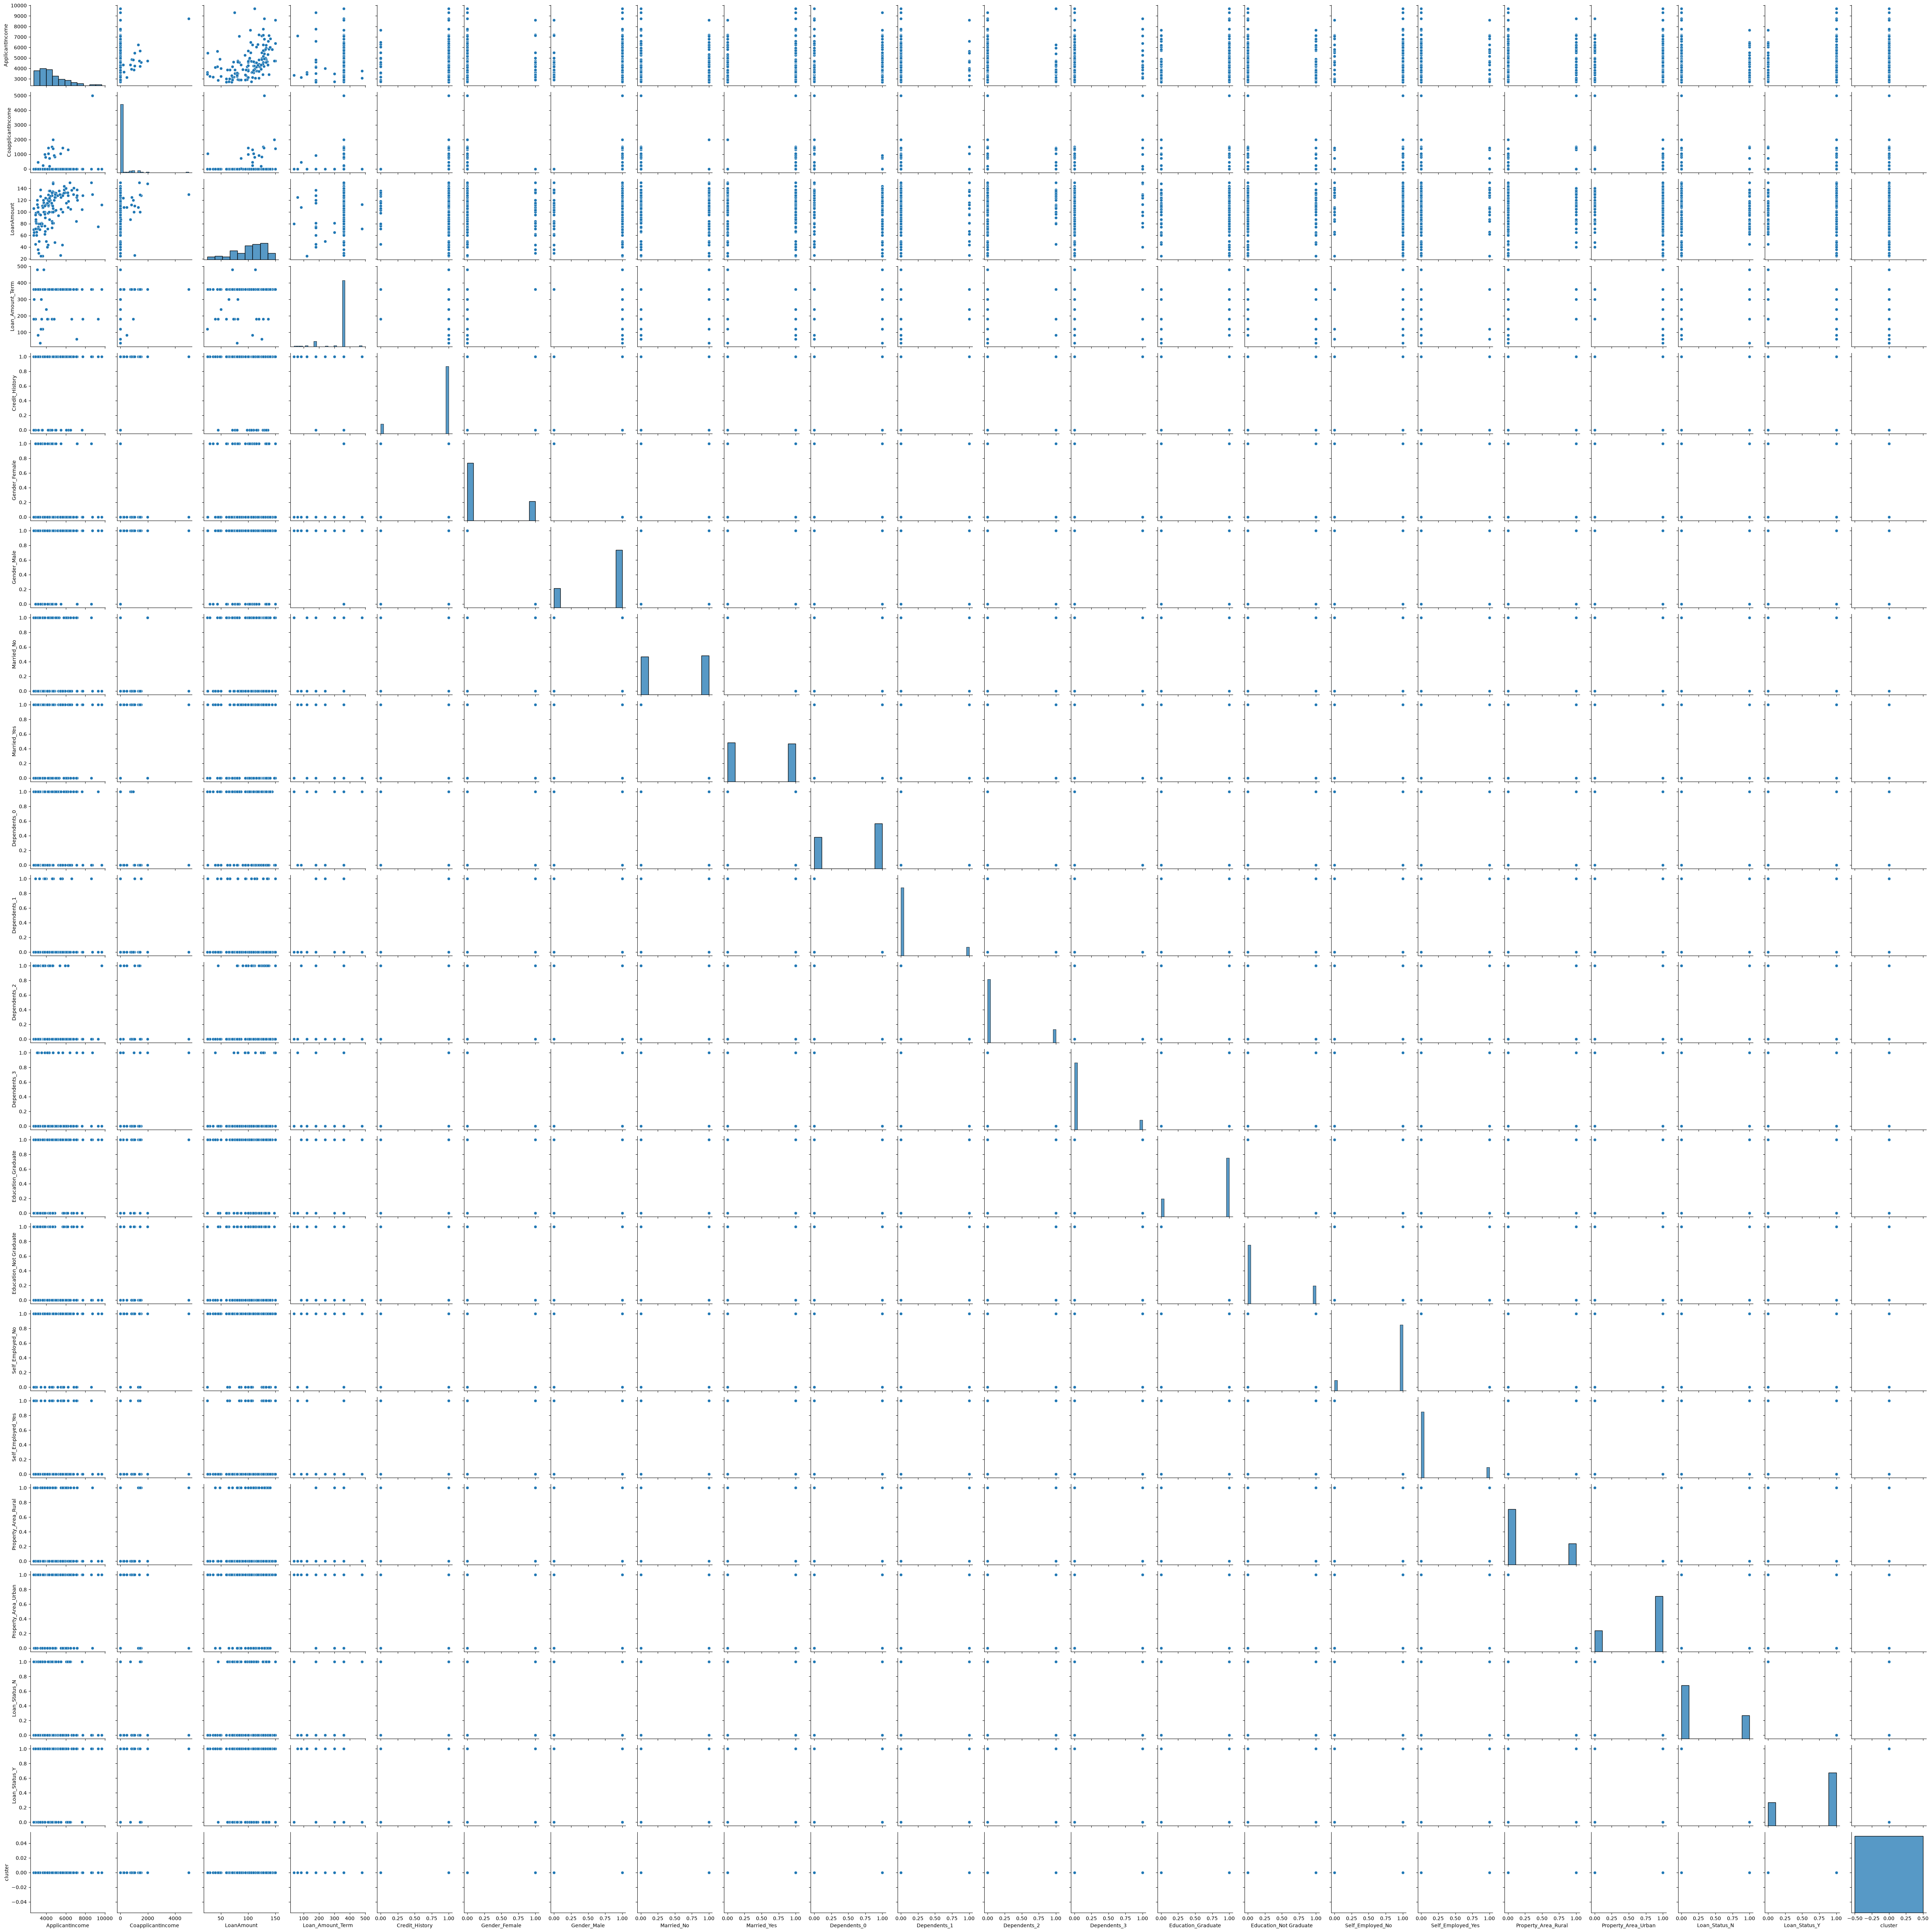

In [38]:
import seaborn as sns
sns.pairplot(c0)

In [39]:
data = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv')

In [40]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [41]:
data.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [42]:
data.columns

Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen'],
      dtype='str')

In [44]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, init='k-means++')
kmeans.fit(data)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](2, 8)",

In [46]:
kmeans.inertia_

113217528878.79834

Text(0, 0.5, 'Inertia')

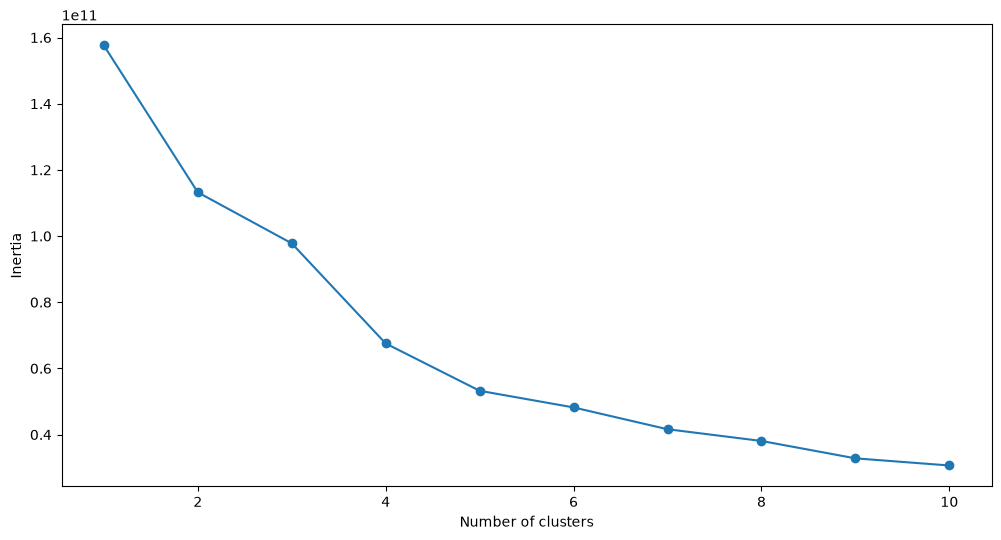

In [51]:
WCSS = []
for cluster in range(1,11):
    kmeans = KMeans(n_clusters =cluster)
    kmeans.fit(data)
    WCSS.append(kmeans.inertia_)

plt.figure(figsize=(12,6))
plt.plot(range(1,11),WCSS, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')


In [52]:
kmeans = KMeans(n_clusters = 5)
kmeans.fit(data)
pred = kmeans.predict(data)
pred

array([3, 1, 3, 3, 4, 3, 3, 3, 3, 1, 1, 3, 4, 1, 4, 3, 1, 3, 3, 3, 3, 3,
       4, 2, 4, 3, 3, 3, 1, 4, 3, 3, 3, 4, 3, 1, 4, 1, 1, 4, 4, 3, 1, 1,
       3, 1, 1, 2, 3, 1, 3, 3, 4, 1, 4, 3, 2, 1, 3, 3, 3, 2, 3, 1, 3, 2,
       3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 1, 3, 3, 3, 1, 1, 3, 3, 2, 2, 4,
       3, 4, 3, 3, 2, 0, 1, 3, 3, 3, 3, 3, 1, 1, 3, 4, 3, 3, 1, 1, 3, 1,
       3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 3, 3, 3, 4, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 3, 3, 1, 3, 3, 3, 4, 3, 3, 3, 3,
       3, 1, 1, 3, 1, 1, 1, 3, 3, 1, 3, 1, 1, 3, 3, 3, 1, 1, 3, 1, 3, 1,
       4, 3, 3, 3, 3, 4, 1, 0, 3, 3, 3, 1, 1, 1, 3, 3, 3, 1, 3, 3, 4, 1,
       3, 3, 1, 1, 4, 3, 3, 1, 3, 3, 3, 1, 3, 2, 3, 3, 1, 1, 1, 3, 1, 3,
       3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 3, 3, 3, 3, 3, 4, 4, 4,
       3, 3, 1, 1, 3, 3, 3, 3, 3, 2, 3, 4, 3, 4, 3, 3, 4, 4, 3, 3, 3, 3,
       1, 1, 1, 3, 1, 3, 3, 3, 3, 4, 3, 3, 4, 3, 3, 3, 3, 3, 4, 4, 4, 4,
       3, 3, 3, 4, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 3,

In [53]:
data.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [54]:
data['Cluster_No'] = pred
data.Cluster_No.value_counts()

Cluster_No
3    275
1     94
4     57
2     11
0      3
Name: count, dtype: int64

In [55]:
cluster0 = data[data.Cluster_No==0]
cluster1= data[data.Cluster_No==1]
cluster2= data[data.Cluster_No==2]
cluster3= data[data.Cluster_No==3]
cluster4= data[data.Cluster_No==4]

In [56]:
cluster_0 = data.groupby('Cluster_No').get_group(0)
cluster_1 = data.groupby('Cluster_No').get_group(1)
cluster_2 = data.groupby('Cluster_No').get_group(2)
cluster_3 = data.groupby('Cluster_No').get_group(3)
cluster_4 = data.groupby('Cluster_No').get_group(4)

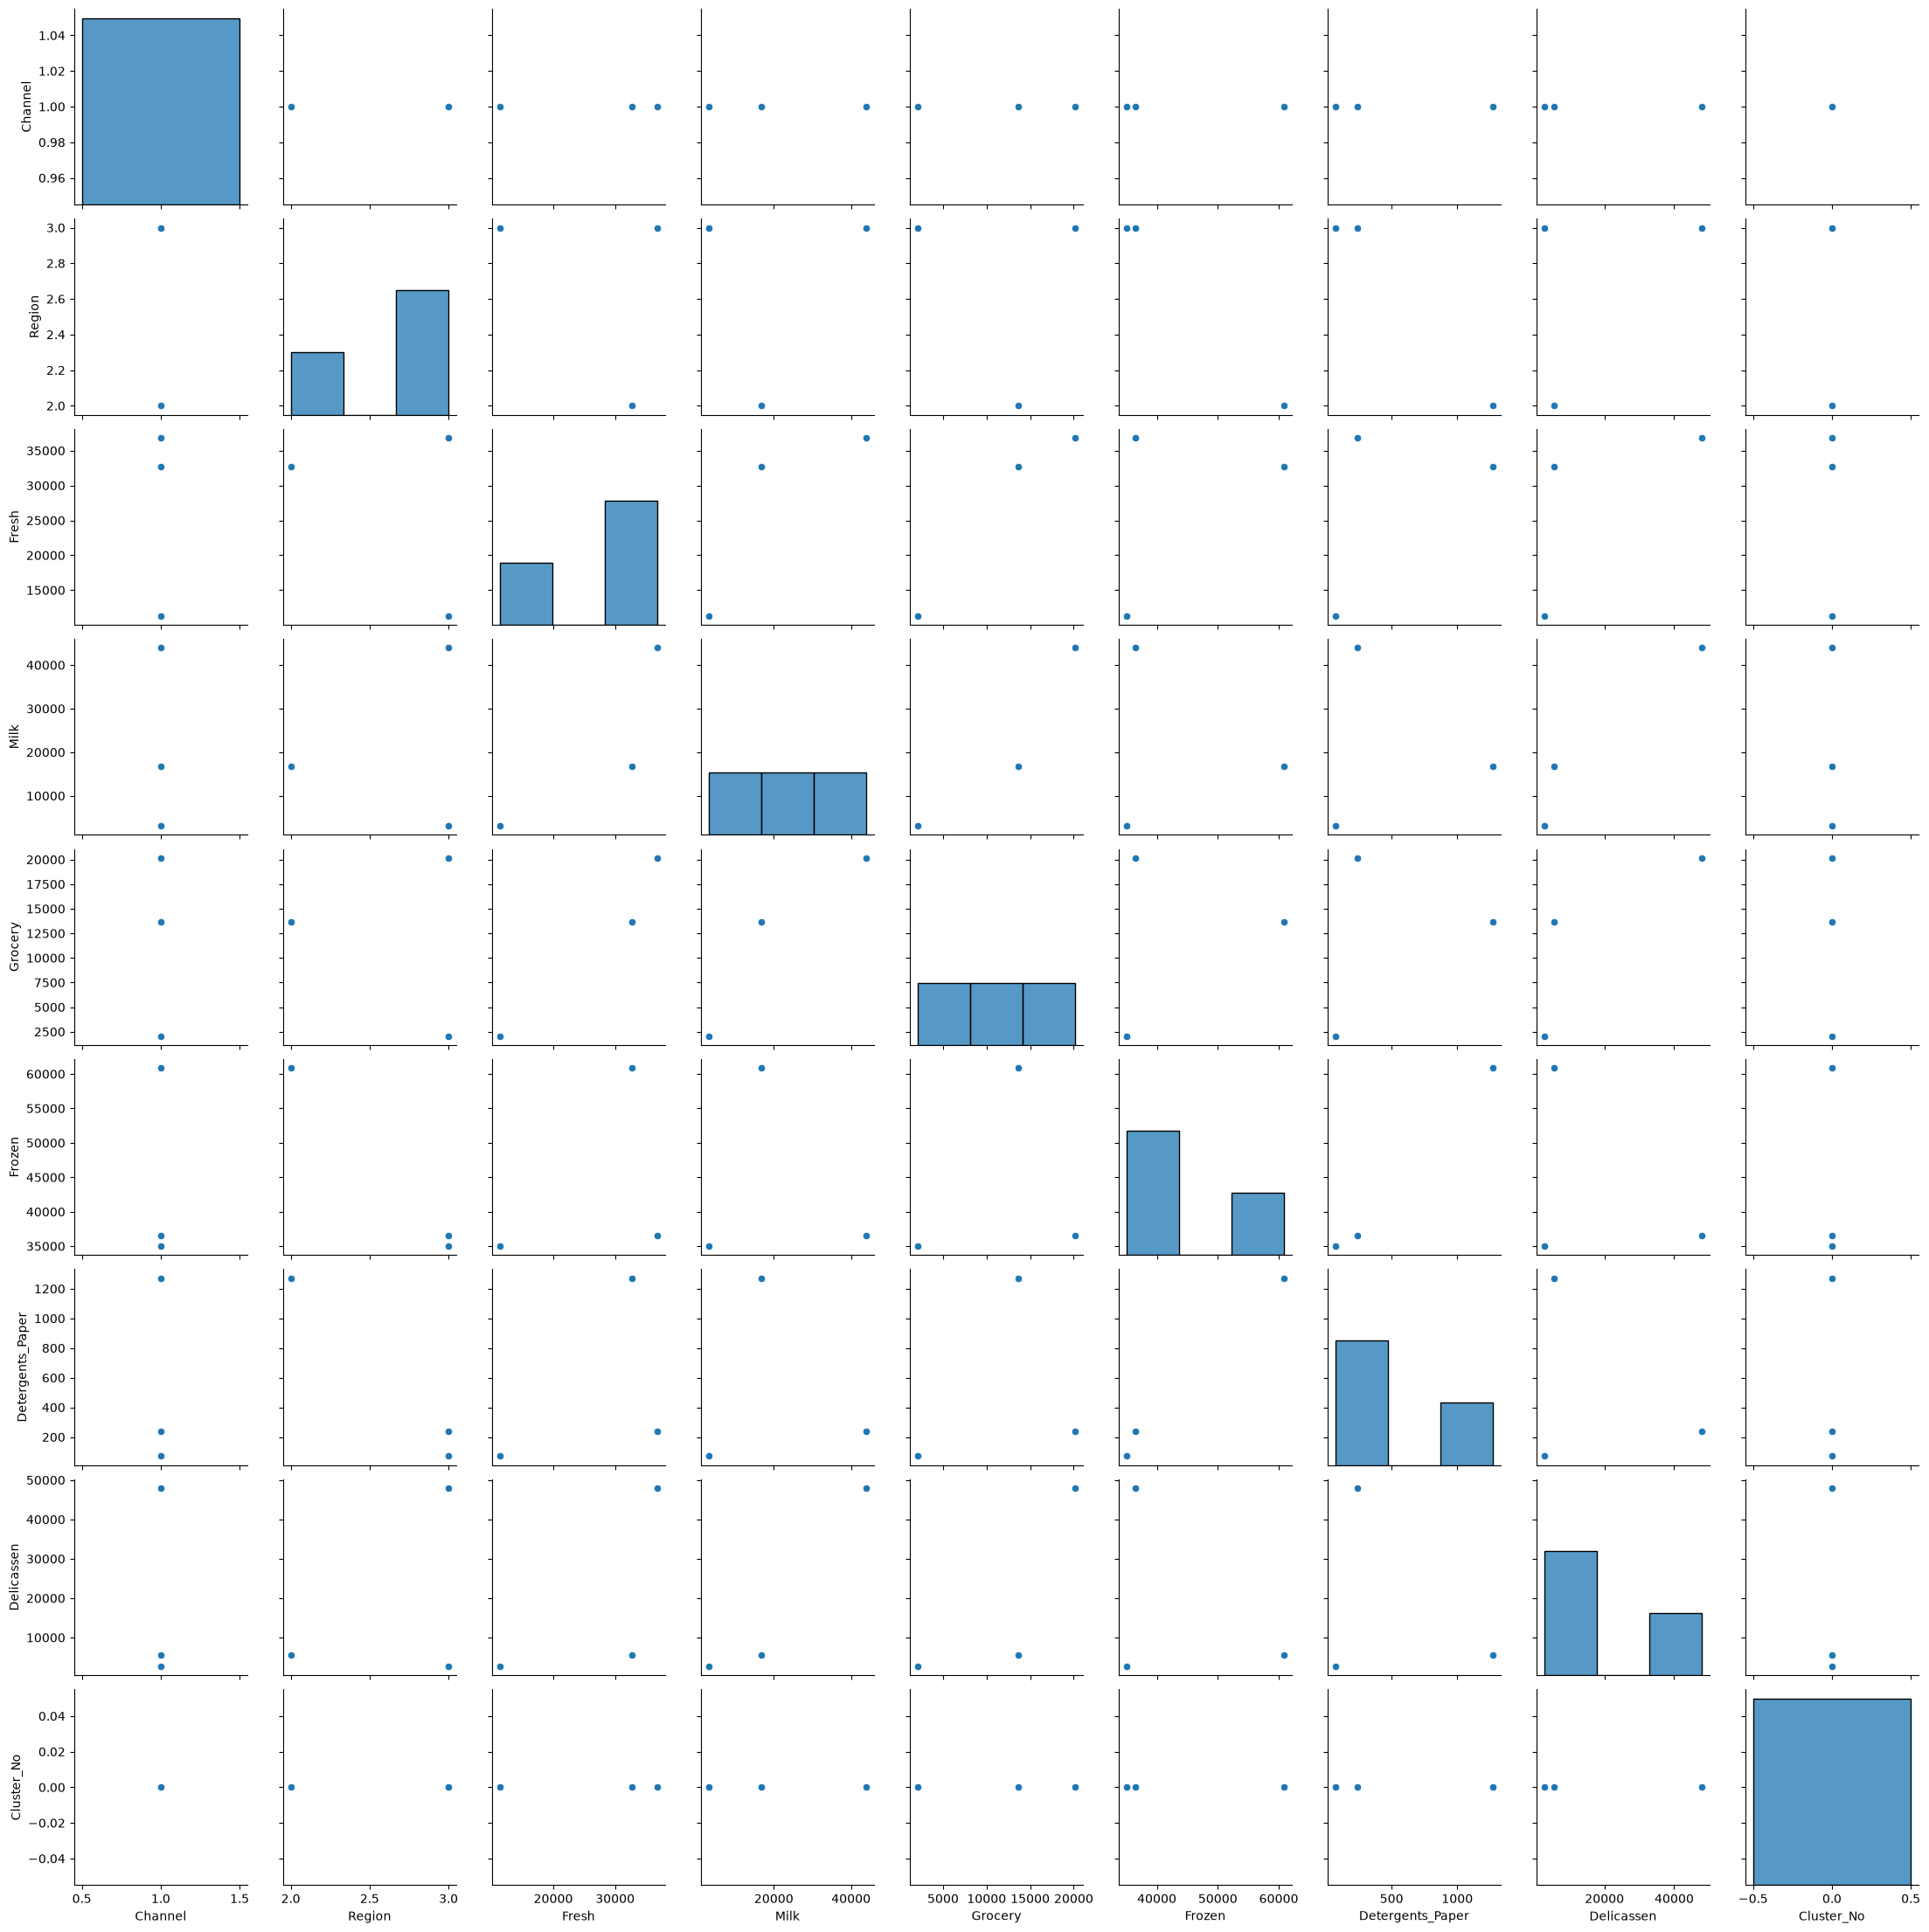

In [57]:
import seaborn as sns
sns.pairplot(cluster0)